In [1]:
%env SPECTRAL_CONNECTIVITY_ENABLE_GPU=true

env: SPECTRAL_CONNECTIVITY_ENABLE_GPU=true


In [2]:
import os

# cuda_bin = r"C:\Users\zhaoz\miniforge3\envs\lfp_env\Library\bin"

# # Add CUDA DLL folder to Windows DLL search path
# os.add_dll_directory(cuda_bin)

# # Add it to PATH for packages that search PATH
# os.environ["PATH"] = cuda_bin + os.pathsep + os.environ["PATH"]

# # Enable GPU mode for spectral_connectivity
# os.environ["SPECTRAL_CONNECTIVITY_ENABLE_GPU"] = "true"

# print("CUDA DLL path added:", cuda_bin)
# print("GPU flag:", os.environ["SPECTRAL_CONNECTIVITY_ENABLE_GPU"])

In [3]:
import sys
print(sys.executable)

os.environ["CUDA_PATH"] = "/apps/compilers/cuda/12.4.1"
os.environ["CUDA_HOME"] = "/apps/compilers/cuda/12.4.1"
os.environ["CONDA_PREFIX"] = sys.prefix

print(os.environ.get("CUDA_PATH"))
print(os.environ.get("CUDA_HOME"))
print("sys.prefix:", sys.prefix)

/blue/npadillacoreano/zishuzhao/.conda/envs/lfp_env/bin/python
/apps/compilers/cuda/12.4.1
/apps/compilers/cuda/12.4.1
sys.prefix: /blue/npadillacoreano/zishuzhao/.conda/envs/lfp_env


In [4]:
import numpy as np
import cupy as cp

x = cp.array([1, 2, 3])
print(cp.linalg.norm(x))
cp.cuda.Stream.null.synchronize()
print("VS Code Jupyter GPU calculation worked")

3.7416573867739413
VS Code Jupyter GPU calculation worked


In [5]:
os.chdir('/blue/npadillacoreano/zishuzhao/diff_fam_social_memory_ephys')
import cupy as xp
from cupyx.scipy.fft import ifft
from cupyx.scipy.sparse.linalg import svds
from spectral_connectivity import Multitaper, Connectivity
import importlib
import pandas as pd
from itertools import combinations
from bidict import bidict
import lfp.lfp_analysis.LFP_collection as LFP_collection
import pickle 
def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl
    Returns:
        none
    """
    with open(file_name, "wb") as file:
        pickle.dump(thing_to_pickle, file)
def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, "rb") as file:
        return pickle.load(file)

df = pd.read_excel(r"./lfp/input/channel_mapping.xlsx")
spike_cols = [col for col in df.columns if 'spike_interface_' in col.lower()]
print(df)

# # Extract brain regions from column names
# # Assumes format 'spike_interface_REGION'
# brain_regions = [col.split('spike_interface_')[1] for col in spike_cols]

# # Create nested dictionary
# subject_to_channel_dict = {}







# for _, row in df.iterrows():
#     subject = row['Subject'].astype(str)
#     # Initialize inner dictionary for this subject
#     subject_to_channel_dict[subject] = {}
    
#     # Populate inner dictionary with brain region: spike value pairs
#     for col, region in zip(spike_cols, brain_regions):
#         subject_to_channel_dict[subject][region] = int(row[col])
behavior_dicts = {}

def make_recording_to_subj_dict(data_path):
    recording_to_subject = {}
    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith('merged.rec'):
                subject = str((file.split("_")[-2]).replace('-', '.'))
                recording_to_subject[file] = subject
                behavior_dicts[file] = {}
    return recording_to_subject

# def process(data_path):
#     recording_to_subject = make_recording_to_subj_dict(data_path)
#     print(recording_to_subject)
#     collection = LFP_collection.LFPCollection(subject_to_channel_dict, data_path, recording_to_subject, 4)
#     #collection.process()
#     return collection    
    




/blue/npadillacoreano/zishuzhao/.conda/envs/lfp_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Cohort  Subject  eib_mPFC  eib_vHPC  eib_BLA  eib_LH  eib_MD  \
0       1      6.1       NaN        15       14      13      31   
1       1      6.2       NaN        15       14      13      31   
2       1      6.3       NaN        15       14      13      31   
3       1      6.4       NaN        15       14      13      31   
4       2      1.1       NaN        16       17      18      19   
5       2      1.2       NaN        31       30      29      28   
6       2      1.3       NaN        15       14      13      12   
7       2      1.4       NaN        15       14      13      12   

   spike_interface_mPFC  spike_interface_vHPC  spike_interface_BLA  \
0                  21.0                  15.0                 14.0   
1                   NaN                   NaN                  NaN   
2                   NaN                   NaN                  NaN   
3                   NaN                   NaN                  NaN   
4                   5.0                  31.0 

In [6]:
# os.chdir('/blue/npadillacoreano/')

In [7]:
data_path = r"other_peoples_sutff/Catherine/lfp_eli"
recording_to_subject = make_recording_to_subj_dict(data_path)
subject_to_channel_dict = {}
for subject in recording_to_subject.values():
    if subject == '6.1':
        mpfc = 14
    if subject == '6.3':
        mpfc = 17
    if subject == '2.1':
        mpfc = 18
    if subject == '2.4': #ramping here
        mpfc = 1 
    if subject == '1.3':
        mpfc = 3
    if subject == '1.2': #minimal ramping in channels 2+ 3
        mpfc = 16
    if subject == '4.2':
        mpfc = 18
    if subject == '4.3':
        mpfc = 19
    if subject == '4.4':
        mpfc = 14
    if subject == '4.1':
        mpfc = 9
    subject_to_channel_dict[subject] = {'mPFC': mpfc, 'IC': 27, 'NAc': 28, 'MD': 29, 'LH': 30, 'BLA': 31}


In [41]:
# Get event dictionary for this recording
all_recordings = unpickle_this(r"other_peoples_sutff/Catherine/lfp_eli/Stage4_D1.pkl")
event = {f"{key}.rec": value for key, value in all_recordings.items()}
print(event['20250508_112121_Stage4_D1_6-1_merged.rec']['coop light'])


[[  28.42115   33.42125]
 [  73.1116    78.1118 ]
 [  85.39185   90.39195]
 [  95.08215  100.08205]
 [ 119.6123   124.61235]
 [ 130.73245  135.7325 ]
 [ 152.90295  157.90305]
 [ 163.44325  168.44315]
 [ 205.47335  210.47345]
 [ 233.8041   238.80405]
 [ 242.30395  247.3039 ]
 [ 249.5839   254.5841 ]
 [ 261.7241   266.72455]
 [ 290.70445  295.70475]
 [ 299.15455  304.1546 ]
 [ 444.02675  449.02645]
 [ 454.3565   459.3567 ]
 [ 460.87655  465.87665]
 [ 470.0767   475.07675]
 [ 484.64725  489.6469 ]
 [ 870.4317   875.4318 ]
 [ 880.25185  885.2519 ]
 [ 892.802    897.8021 ]
 [ 906.9522   911.9525 ]
 [ 915.7023   920.70235]
 [ 934.60255  939.60285]
 [ 944.69265  949.6927 ]
 [ 952.04275  957.0428 ]
 [ 963.6029   968.60345]
 [ 972.403    977.4033 ]
 [ 982.80315  987.8032 ]
 [ 993.94355  998.9436 ]
 [1006.45345 1011.45335]
 [1024.4037  1029.4037 ]
 [1031.88375 1036.88385]
 [1042.3339  1047.33395]
 [1075.3743  1080.3745 ]
 [1087.20445 1092.20475]
 [1094.28455 1099.2846 ]
 [1104.13495 1109.13485]


In [9]:
collection = LFP_collection.LFPCollection(subject_to_channel_dict, 
                                          data_path, 
                                          recording_to_subject, 5, 
                                          recording_to_event_dict = event)


Processing 20250509_131426_Stage4_D1_4-1_merged.rec
Processing 20250508_100203_Stage4_D1_1-2_merged.rec
Processing 20250509_131426_Stage4_D1_4-3_merged.rec
Processing 20250508_112121_Stage4_D1_6-1_merged.rec
Processing 20250508_100203_Stage4_D1_2-4_merged.rec
Processing 20250508_112121_Stage4_D1_6-3_merged.rec
Processing 20250509_131426_Stage4_D1_4-2_merged.rec
Processing 20250508_100203_Stage4_D1_2-1_merged.rec
Processing 20250508_100203_Stage4_D1_1-3_merged.rec
Processing 20250509_131426_Stage4_D1_4-4_merged.rec


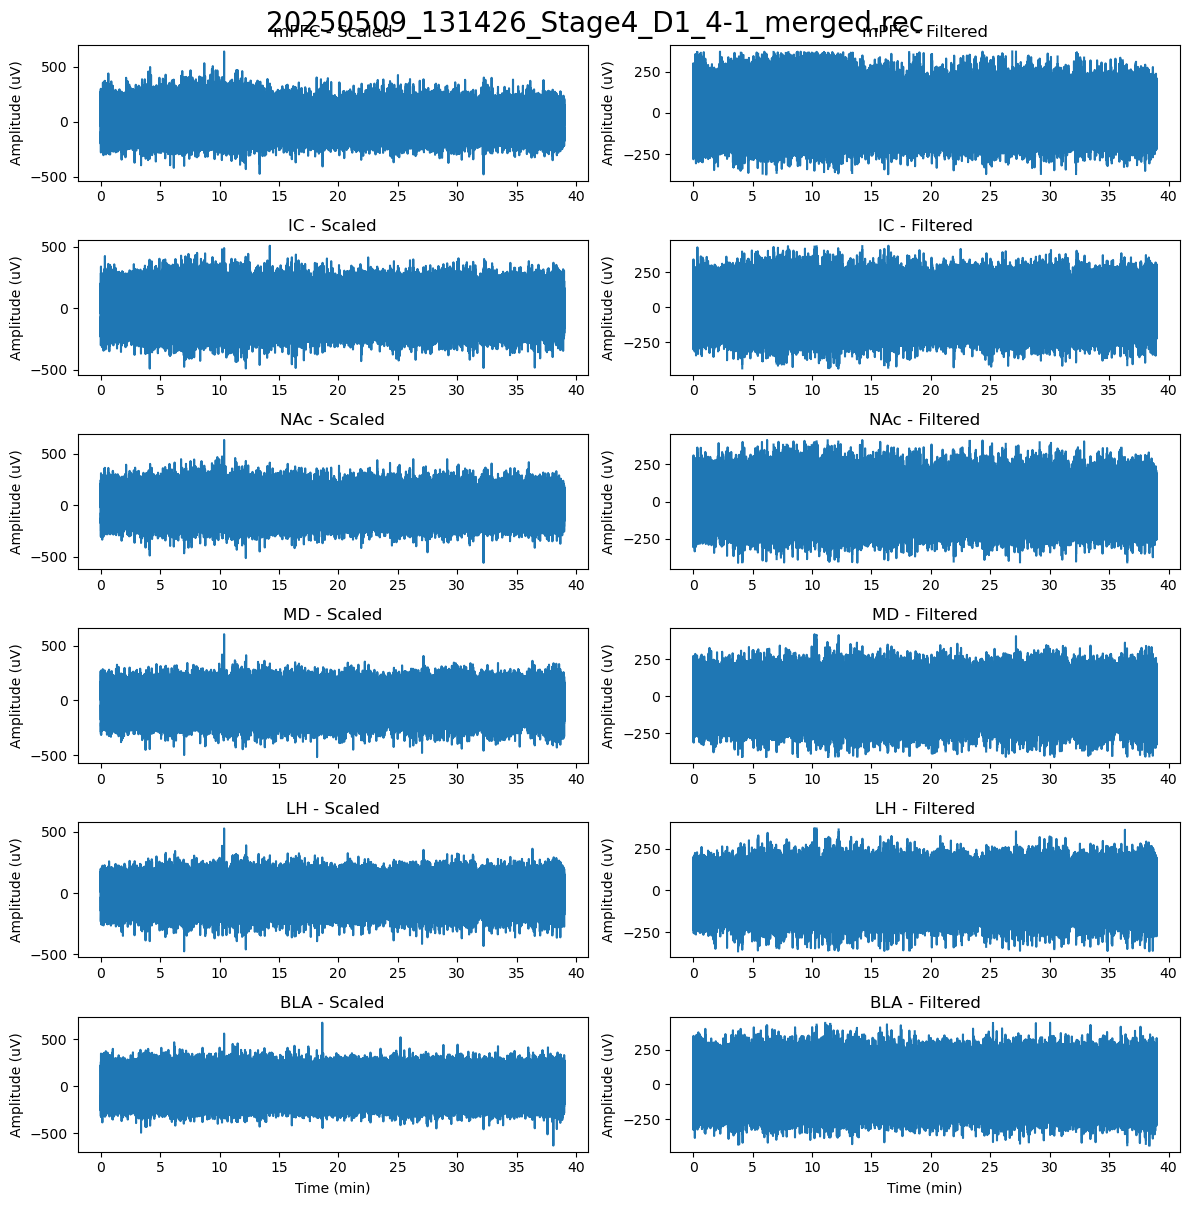

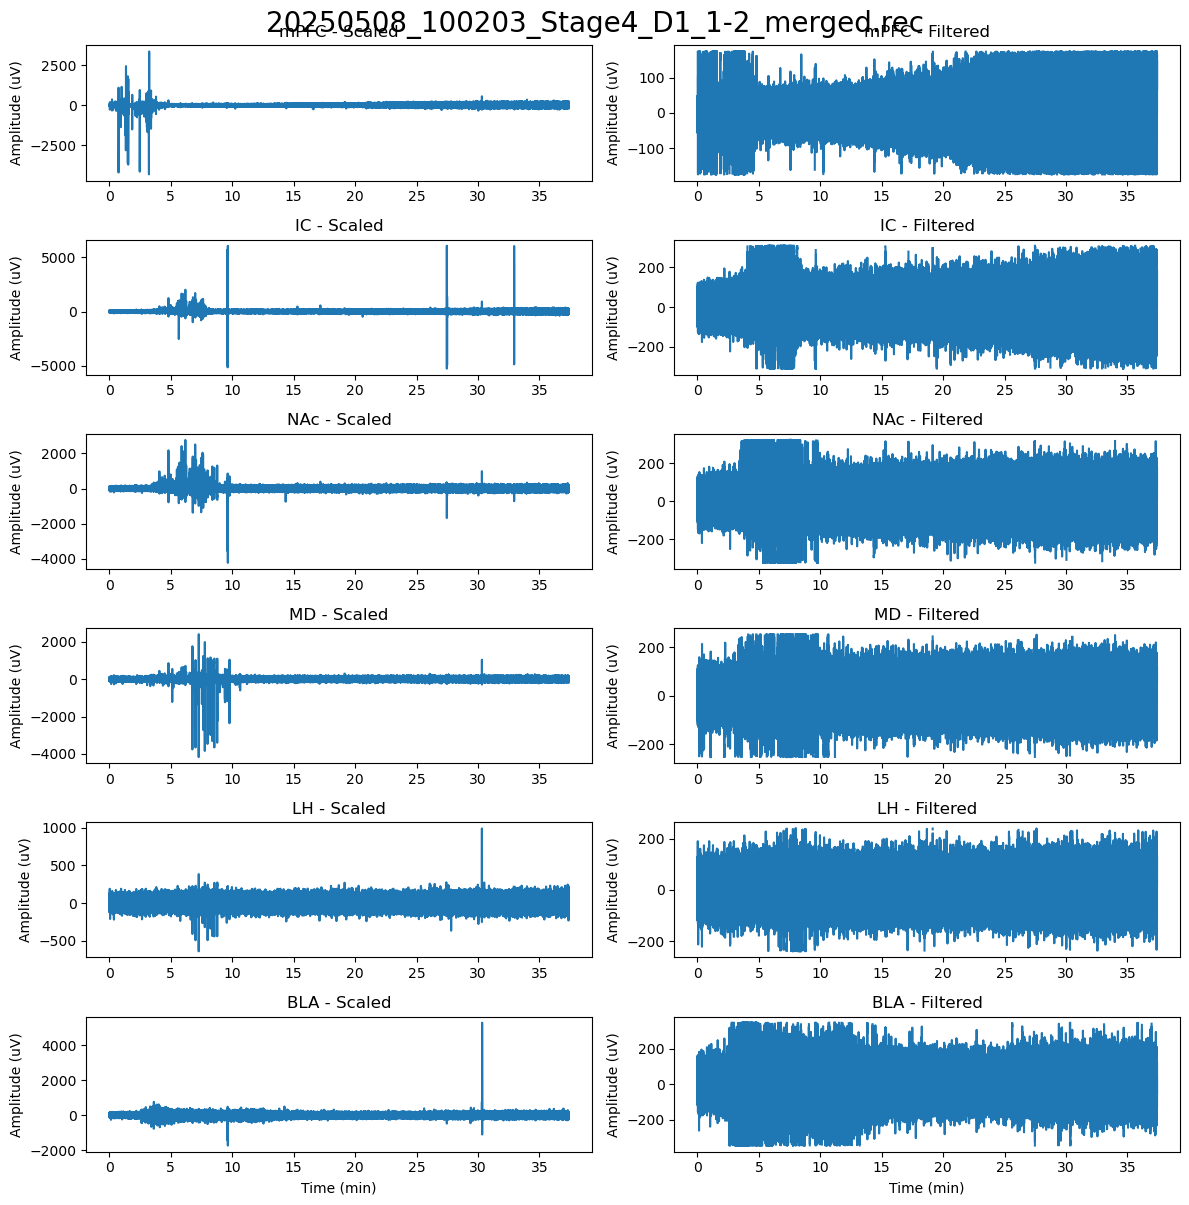

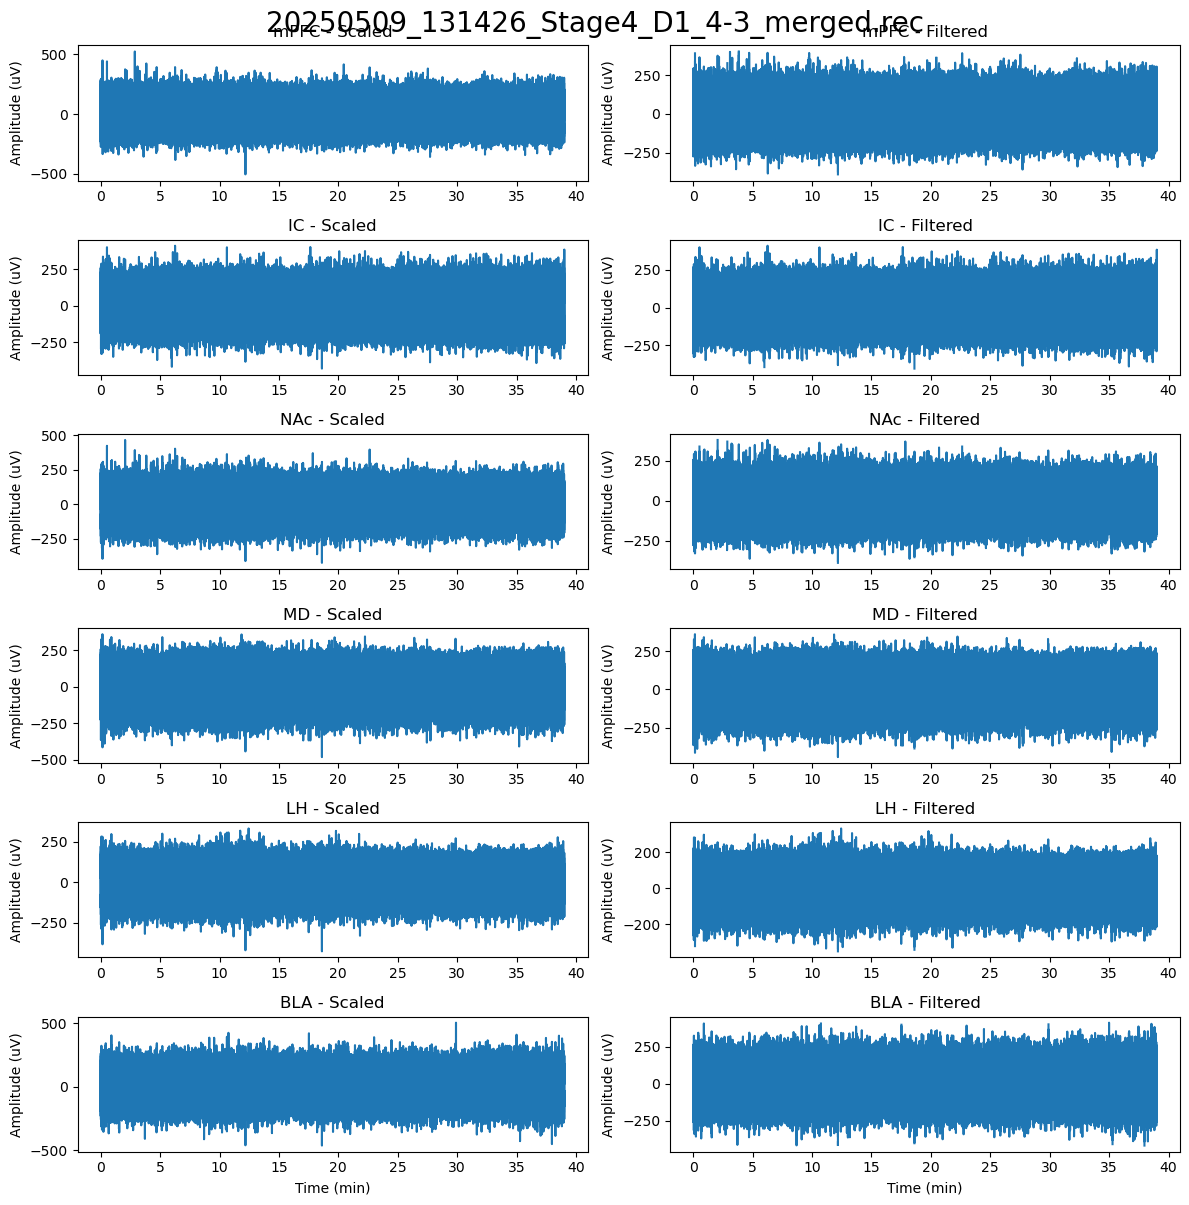

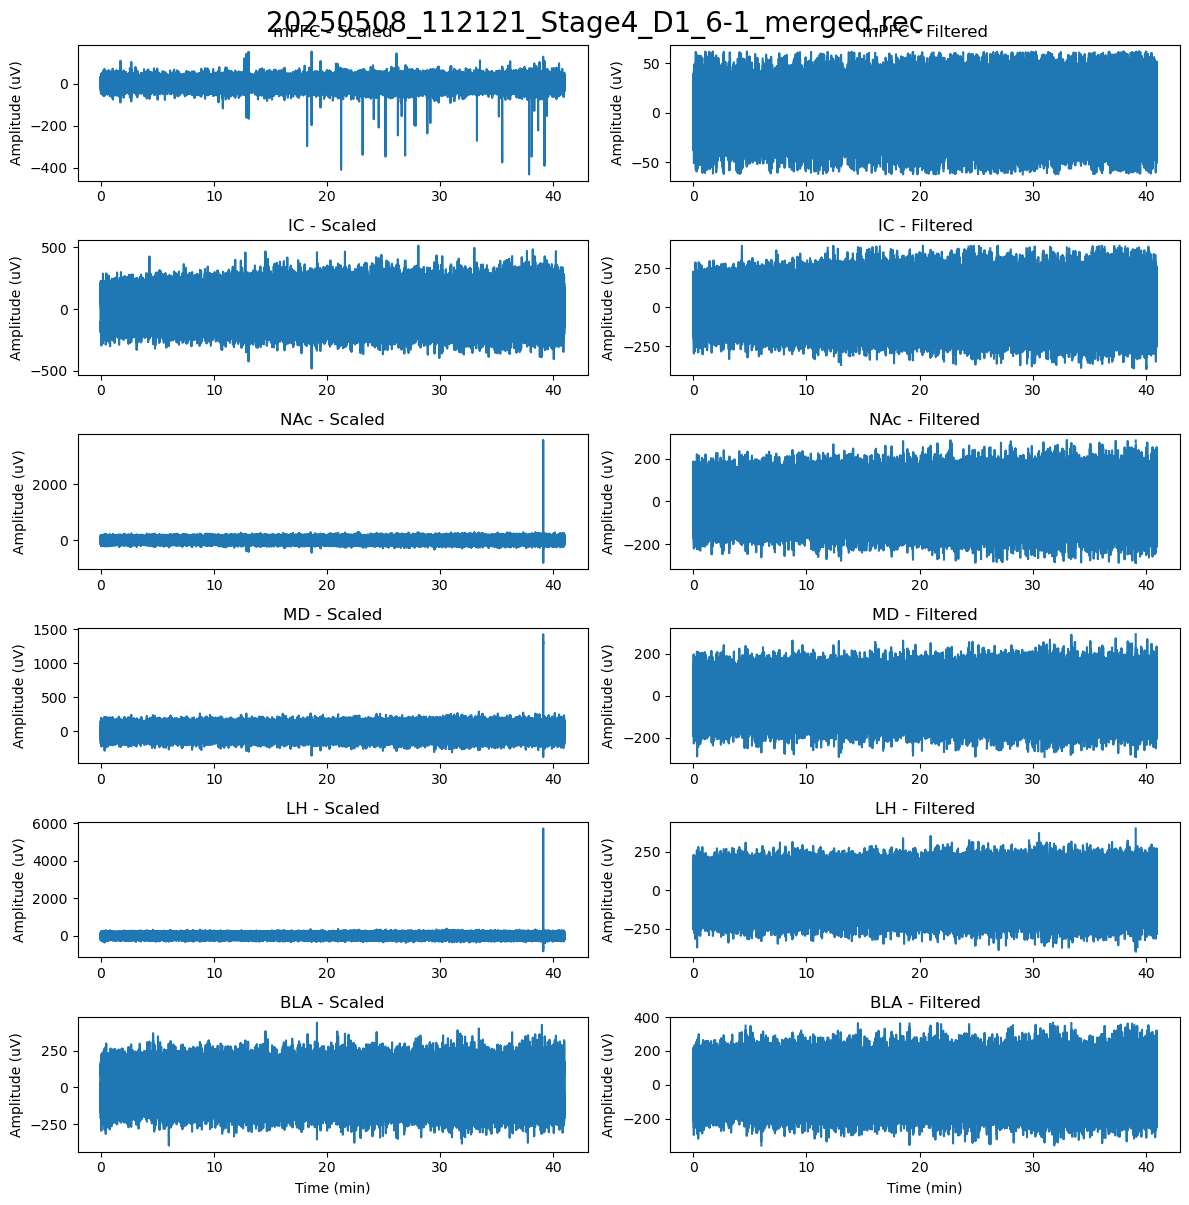

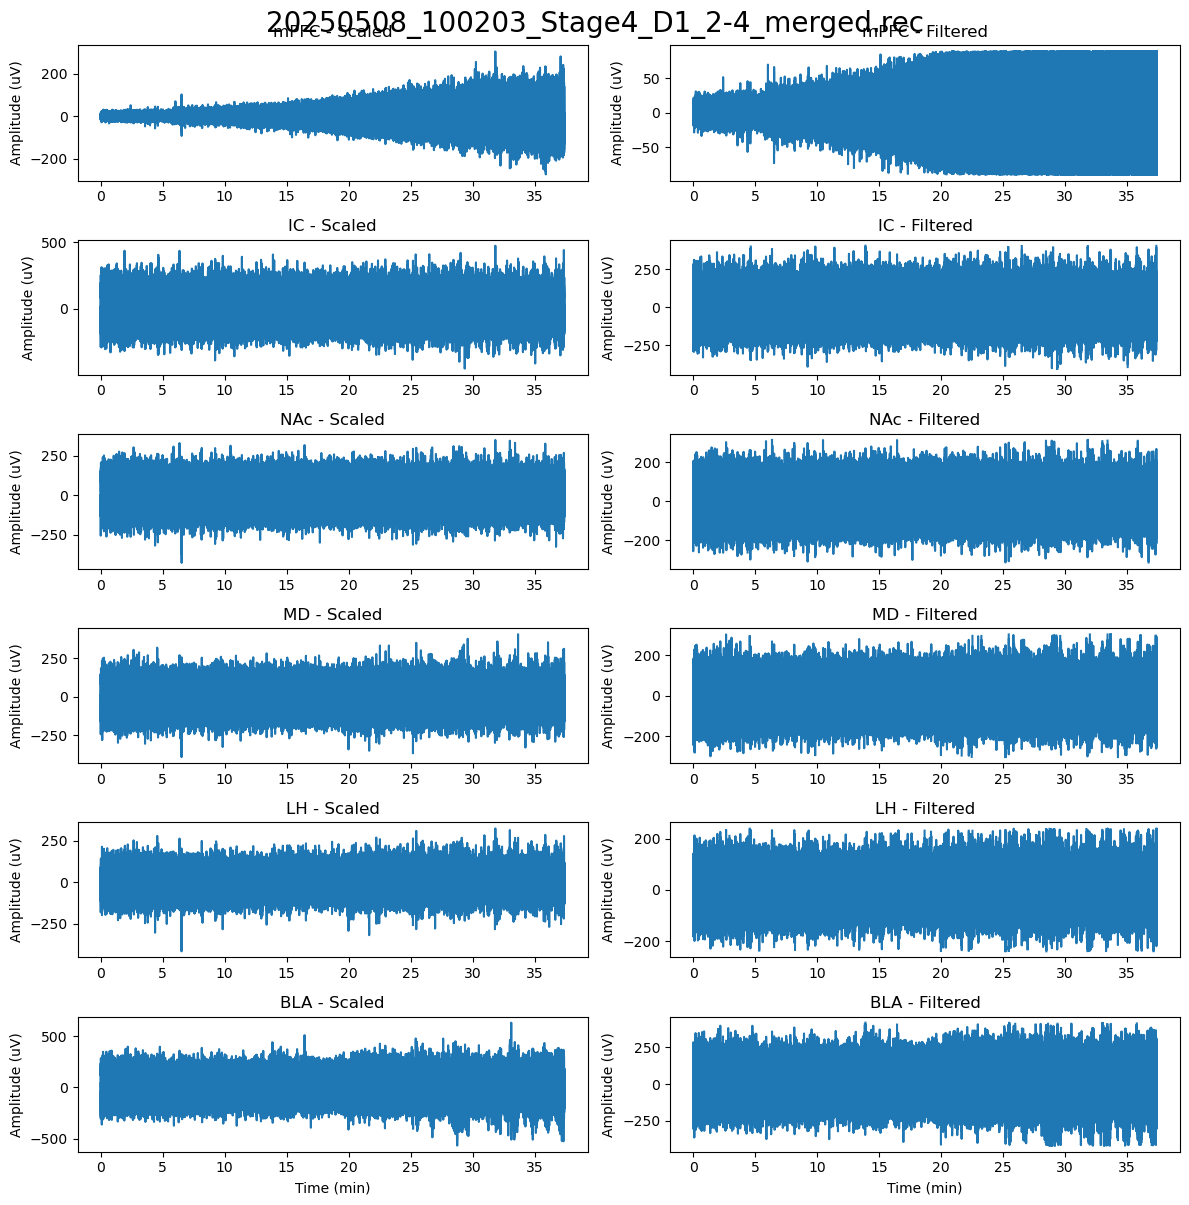

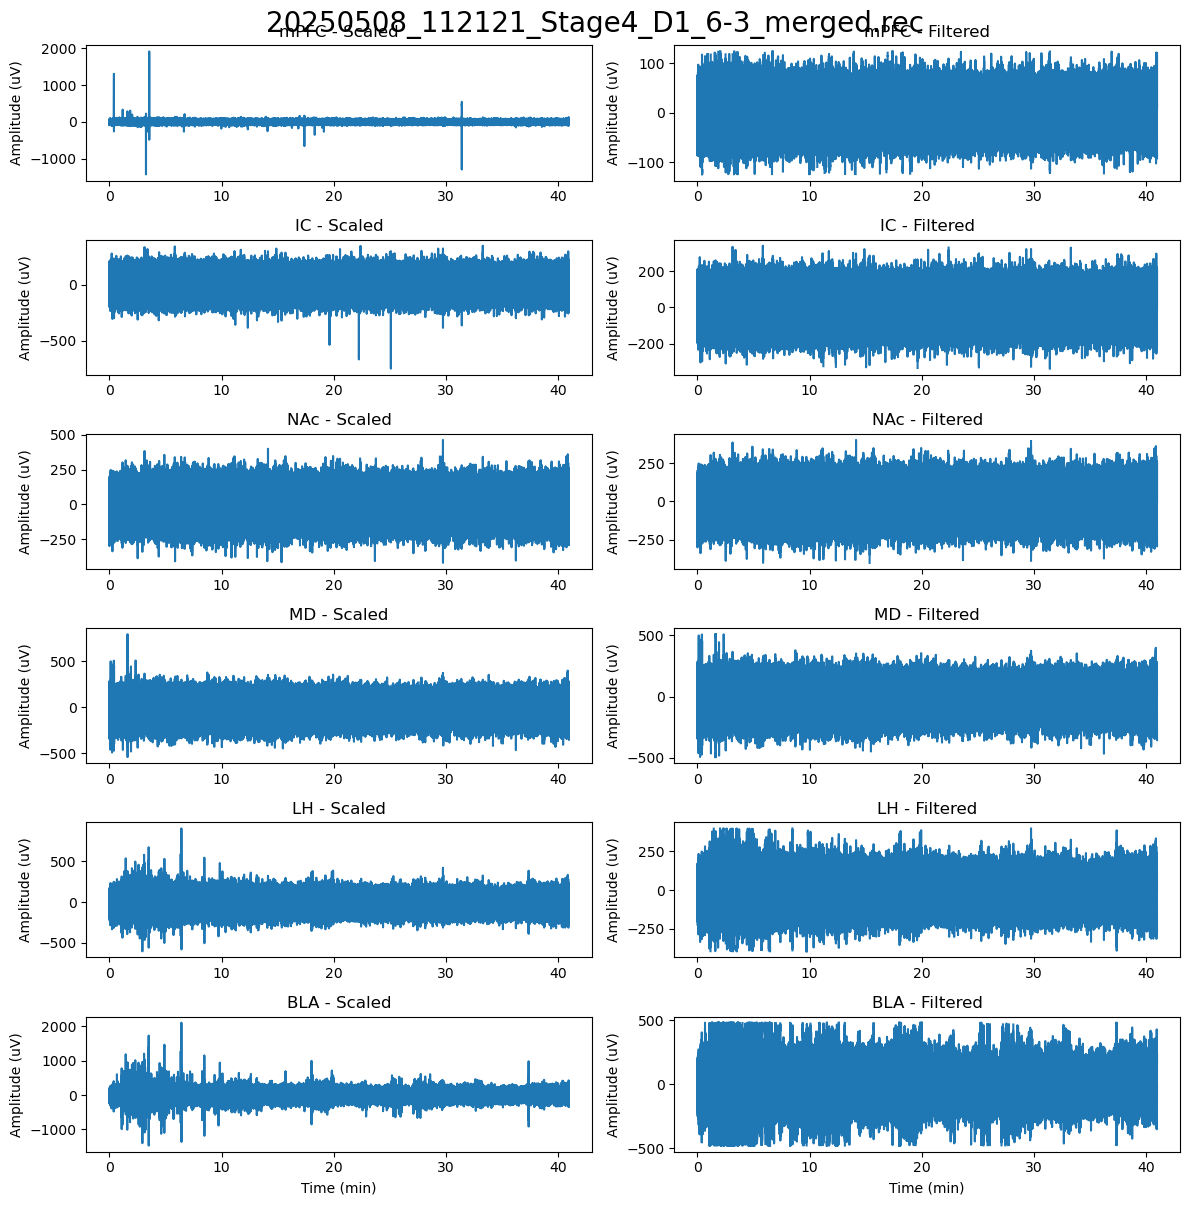

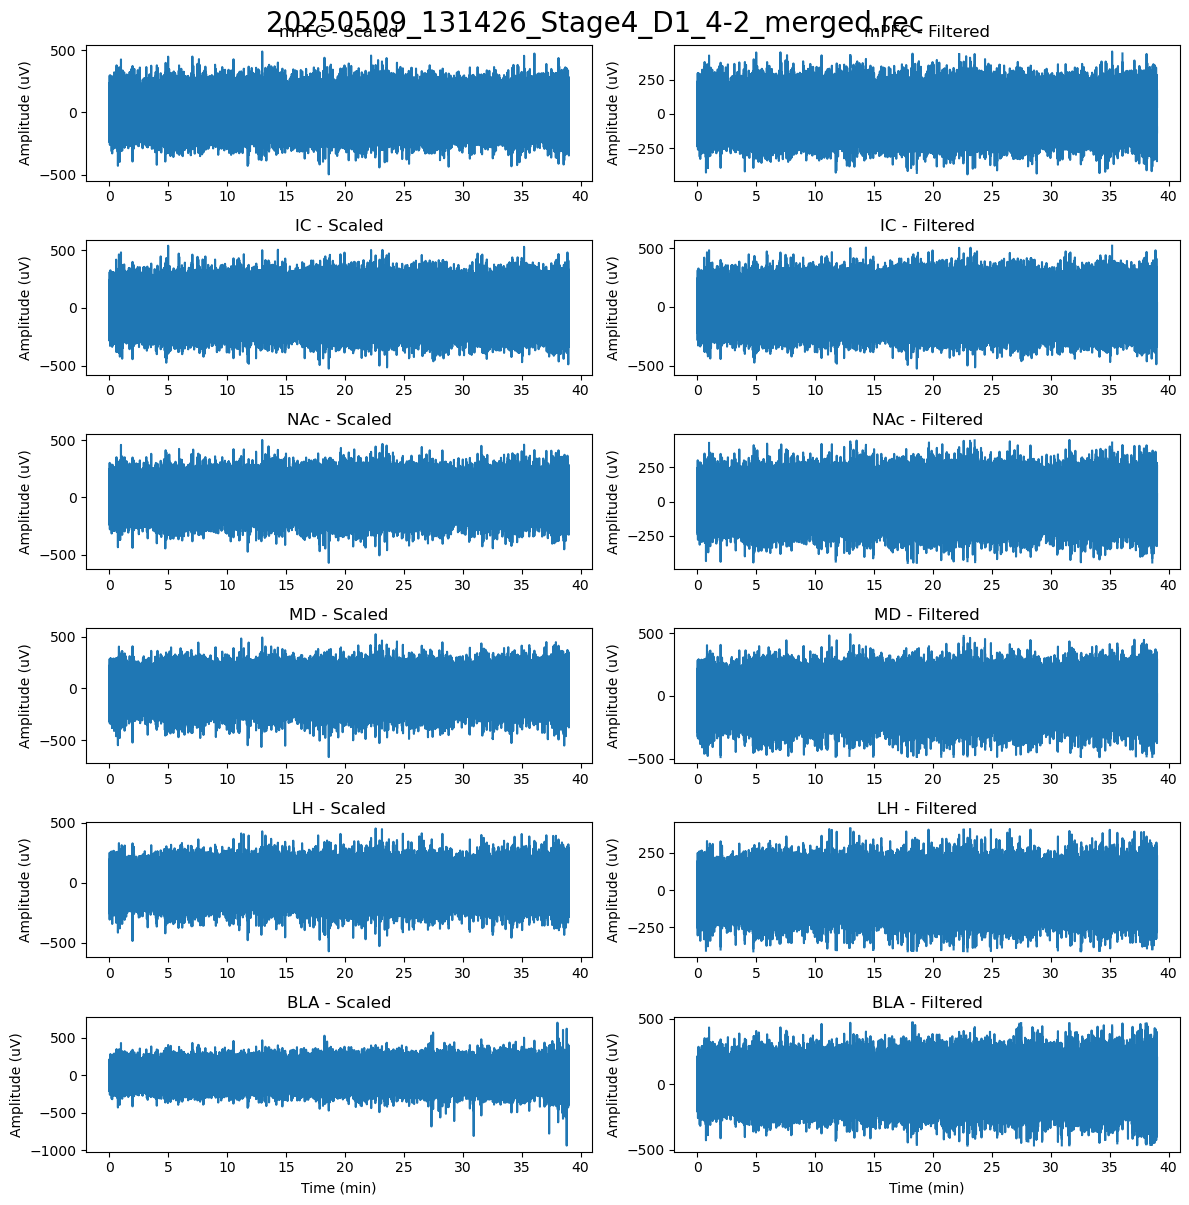

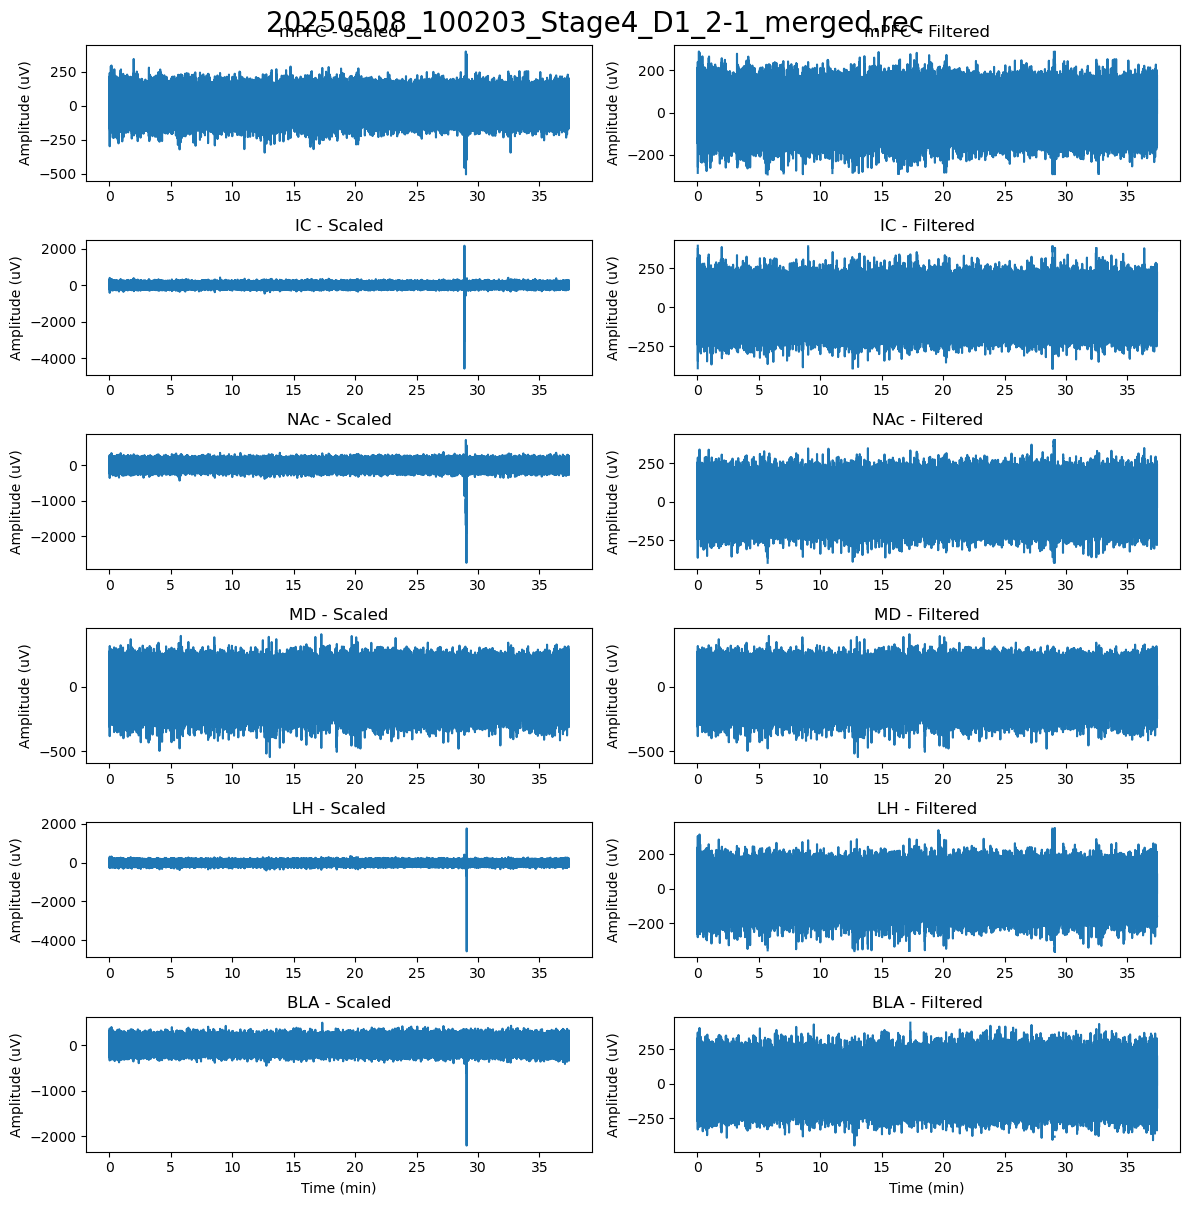

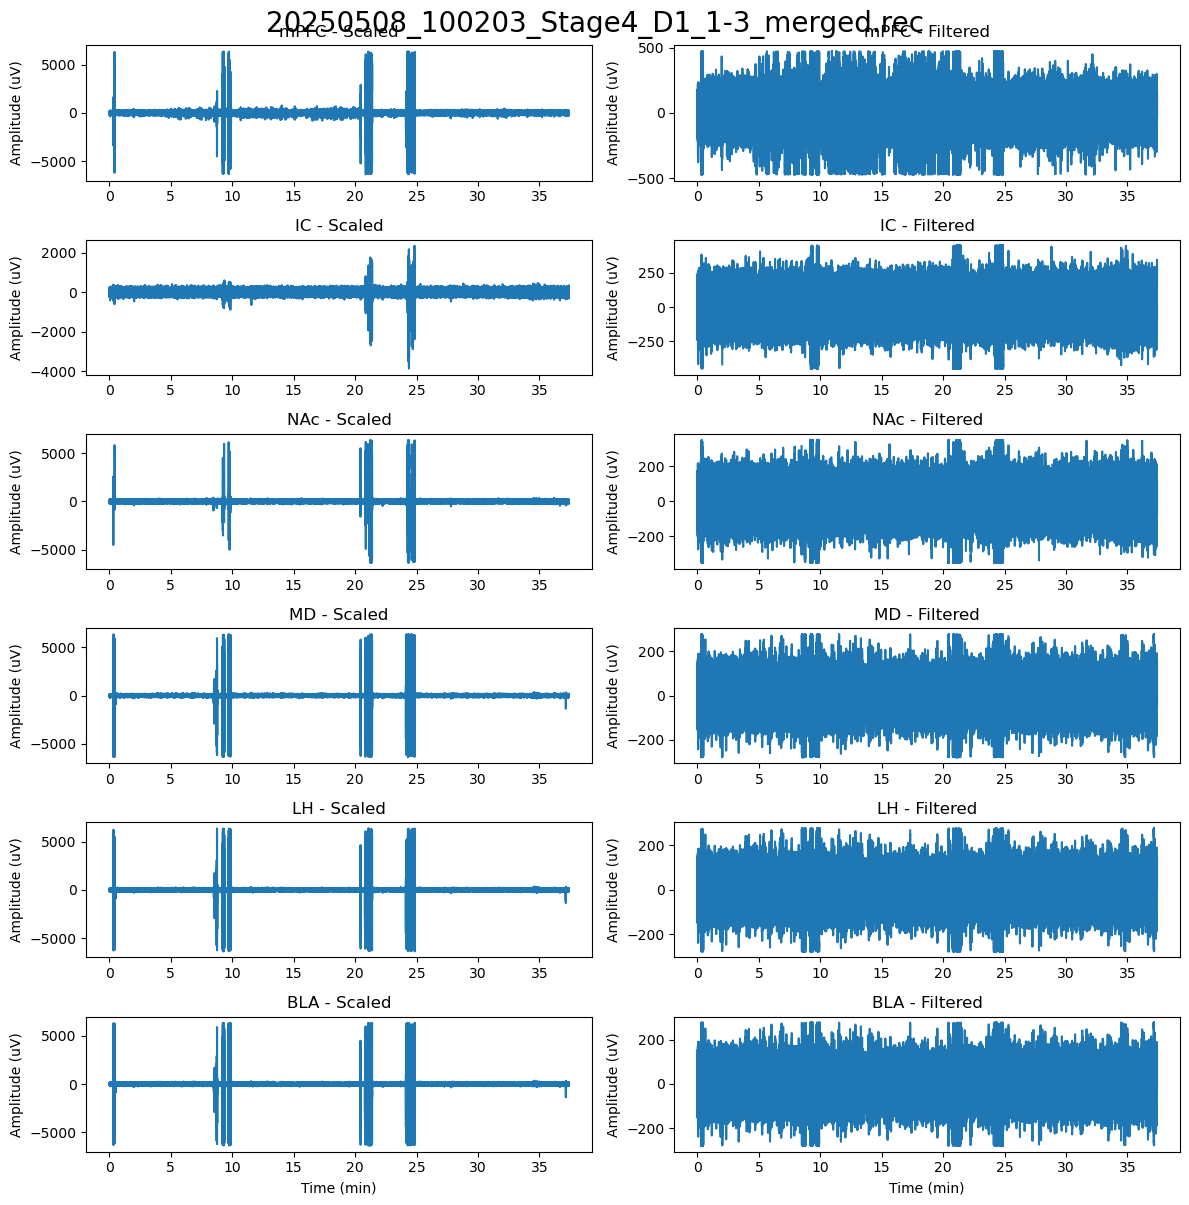

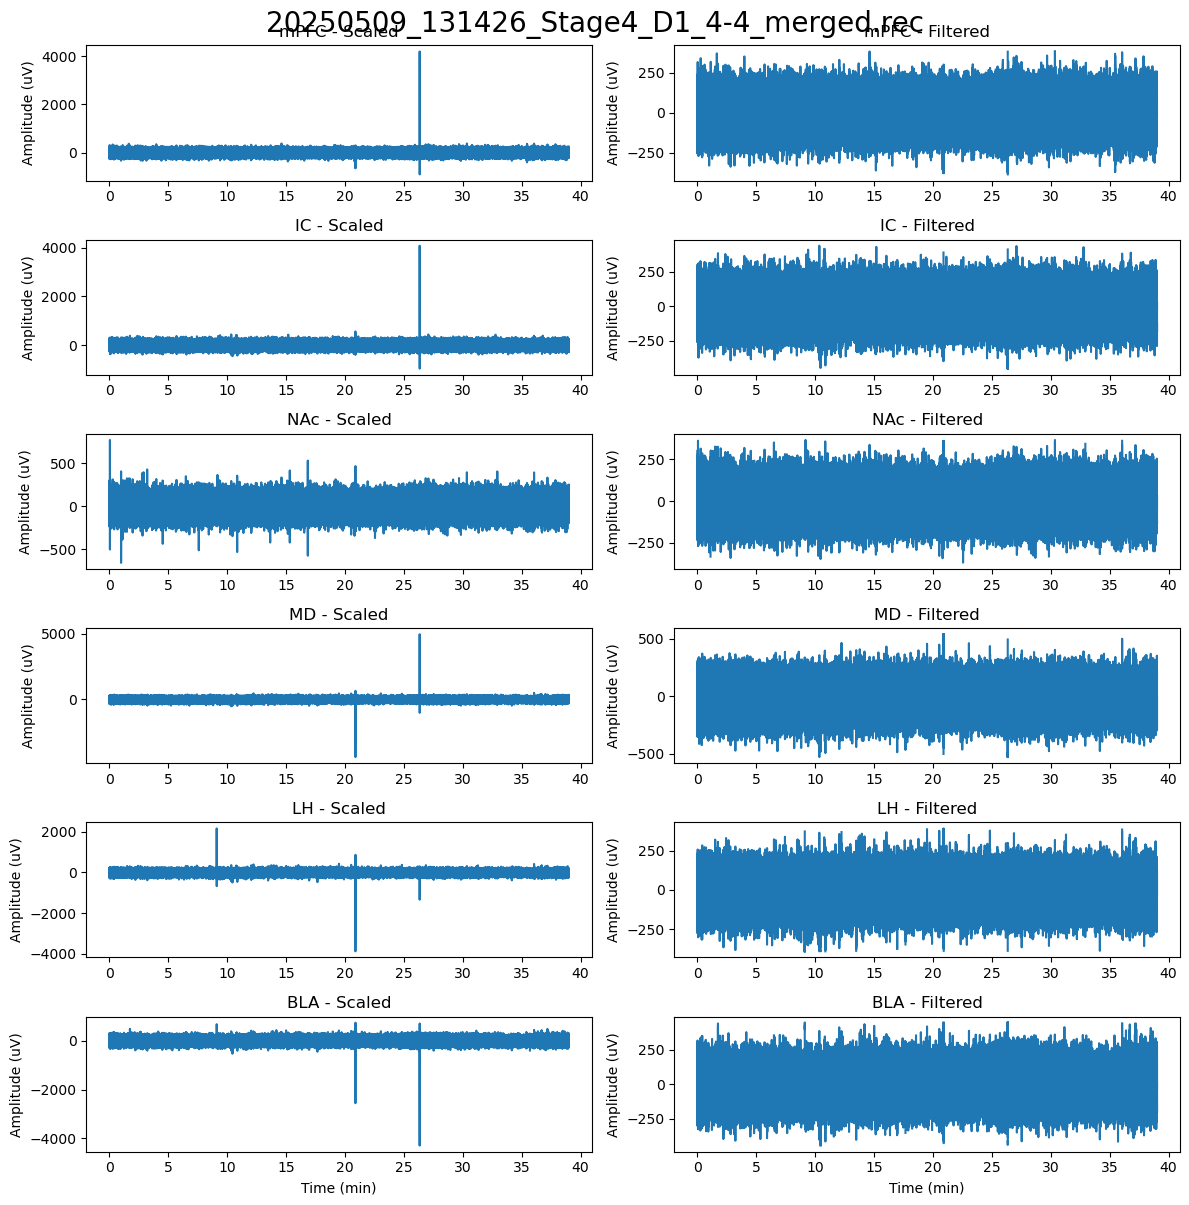

In [10]:
collection.diagnostic_plots(threshold = 5)

In [11]:
# collection.diagnostic_plots_channel_finder()

In [12]:
collection.preprocess(threshold = 5)

  0%|          | 0/10 [00:00<?, ?it/s]

processing 20250509_131426_Stage4_D1_4-1_merged.rec


 10%|█         | 1/10 [00:00<00:05,  1.75it/s]

RMS Traces calculated
processing 20250508_100203_Stage4_D1_1-2_merged.rec


 20%|██        | 2/10 [00:01<00:04,  1.66it/s]

...

RMS Traces calculated
processing 20250508_100203_Stage4_D1_1-3_merged.rec


 90%|█████████ | 9/10 [00:05<00:00,  1.67it/s]

RMS Traces calculated
processing 20250509_131426_Stage4_D1_4-4_merged.rec


100%|██████████| 10/10 [00:06<00:00,  1.61it/s]

RMS Traces calculated


In [13]:
collection.calculate_all()



  0%|          | 0/10 [00:00<?, ?it/s]

Power Calculated


 10%|█         | 1/10 [00:01<00:09,  1.09s/it]

Coherence calcualatd
Power Calculated


 20%|██        | 2/10 [00:01<00:05,  1.56it/s]

...

Granger causality calculated


Maximum iterations reached. 4010 of 4487 converged
Maximum iterations reached. 4002 of 4487 converged
Maximum iterations reached. 3984 of 4487 converged
Maximum iterations reached. 3978 of 4487 converged
Maximum iterations reached. 3976 of 4487 converged
Maximum iterations reached. 4283 of 4487 converged
Maximum iterations reached. 4225 of 4487 converged
Maximum iterations reached. 4222 of 4487 converged
Maximum iterations reached. 4222 of 4487 converged
Maximum iterations reached. 4221 of 4487 converged
Maximum iterations reached. 4217 of 4487 converged
Maximum iterations reached. 4217 of 4487 converged
Maximum iterations reached. 4229 of 4487 converged
Maximum iterations reached. 4227 of 4487 converged
Maximum iterations reached. 4227 of 4487 converged
 90%|█████████ | 9/10 [03:58<00:26, 26.15s/it]

Granger causality calculated


Maximum iterations reached. 4650 of 4680 converged
Maximum iterations reached. 4618 of 4680 converged
Maximum iterations reached. 4638 of 4680 converged
Maximum iterations reached. 4632 of 4680 converged
Maximum iterations reached. 4657 of 4680 converged
Maximum iterations reached. 4610 of 4680 converged
Maximum iterations reached. 4644 of 4680 converged
Maximum iterations reached. 4627 of 4680 converged
Maximum iterations reached. 4653 of 4680 converged
Maximum iterations reached. 4599 of 4680 converged
Maximum iterations reached. 4601 of 4680 converged
Maximum iterations reached. 4622 of 4680 converged
Maximum iterations reached. 4624 of 4680 converged
Maximum iterations reached. 4652 of 4680 converged
Maximum iterations reached. 4628 of 4680 converged
100%|██████████| 10/10 [04:24<00:00, 26.48s/it]

Granger causality calculated


In [10]:
collection.save_to_json(r"other_peoples_sutff/Catherine/lfp_eli/D1_lfp_collection")

NameError: name 'collection' is not defined

In [55]:
collection=LFP_collection.LFPCollection.load_collection(r"other_peoples_sutff/Catherine/lfp_eli/D1_lfp_collection/lfp_collection.json")

In [56]:
from collections import defaultdict
condition_dict = defaultdict(list)

subjects = {"1-2", "2-4", "6-1", "4-4", "4-3"}
recipients = {"1-3", "2-1", "6-3", "4-2", "4-1"}

for recording in collection.recordings:
    animal_pair = recording.name.split("_")[4]

    if animal_pair in subjects:
        recording.condition = "subject"
        condition_dict["subject"].append(recording.name)

    elif animal_pair in recipients:
        recording.condition = "recipient"
        condition_dict["recipient"].append(recording.name)

    else:
        recording.condition = "unknown"
        
# for recording in collection.recordings: 
#     if recording.name == '20250517_121746_Stage8_D8_6-1_merged.rec':
#         recording.condition = 'alone'
#         condition_dict['alone'].append(recording.name)
#     if recording.name == '20250517_121746_Stage8_D8_6-3_merged.rec':
#         recording.condition = 'alone'
#         condition_dict['alone'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_2-1_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_2-4_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_1-3_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_1-2_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-2_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-3_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-4_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-1_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250520_111417_alone_D1_4-2_merged.rec':
#     if recording.name == '20250520_111417_alone_D1_4-1_merged.rec':
#     if recording.name == '20250520_111417_alone_D1_4-3_merged.rec':
    # if recording.name == '20250508_100203_Stage4_D1_1-2_merged.rec':
    #     recording.condition = 'subject'
    #     condition_dict['subject'].append(recording.name)

        
print(condition_dict)

defaultdict(<class 'list'>, {'recipient': ['20250508_112121_Stage4_D1_6-3_merged.rec', '20250509_131426_Stage4_D1_4-2_merged.rec', '20250509_131426_Stage4_D1_4-1_merged.rec', '20250508_100203_Stage4_D1_1-3_merged.rec', '20250508_100203_Stage4_D1_2-1_merged.rec'], 'subject': ['20250508_100203_Stage4_D1_1-2_merged.rec', '20250508_100203_Stage4_D1_2-4_merged.rec', '20250509_131426_Stage4_D1_4-3_merged.rec', '20250509_131426_Stage4_D1_4-4_merged.rec', '20250508_112121_Stage4_D1_6-1_merged.rec']})


In [57]:
for recording in collection.recordings:
    for event_name, events in recording.event_dict.items():
        recording.event_dict[event_name] = np.asarray(events) * 1000

In [58]:
import math
import numpy as np

for recording in collection.recordings:
    if recording.name in condition_recordings["subject alone"]:
        print(recording.name)
        freq_timebin = recording.timestep * 1000
        recording_duration_ms = recording.power.shape[0] * freq_timebin

        print("  recording duration ms:", recording_duration_ms)

        for event_name in ["selfish light", "coop light"]:
            events = np.asarray(recording.event_dict[event_name])

            pre_indices = np.ceil(events[:, 0] / freq_timebin).astype(int)
            post_indices = np.ceil(events[:, 1] / freq_timebin).astype(int)
            widths = post_indices - pre_indices
            within = post_indices < recording.power.shape[0]

            print(event_name)
            print("  raw start min/max:", np.nanmin(events[:, 0]), np.nanmax(events[:, 0]))
            print("  raw stop min/max:", np.nanmin(events[:, 1]), np.nanmax(events[:, 1]))
            print("  raw duration min/max:", np.nanmin(events[:, 1] - events[:, 0]), np.nanmax(events[:, 1] - events[:, 0]))
            print("  post index min/max:", np.nanmin(post_indices), np.nanmax(post_indices))
            print("  within recording:", np.sum(within), "of", len(events))
            print("  bin width min/max:", np.nanmin(widths), np.nanmax(widths))
            print("  zero-width:", np.sum(widths <= 0), "of", len(events))

20250508_112121_Stage4_D1_6-3_merged.rec
  recording duration ms: 2457500.0
selfish light
  raw start min/max: 82381.85 2421191.3
  raw stop min/max: 87381.90000000001 2423425.35
  raw duration min/max: 2234.0500000002794 10000.099999999977
  post index min/max: 175 4847
  within recording: 209 of 209
  bin width min/max: 4 20
  zero-width: 0 of 209
coop light
  raw start min/max: 210403.55 2421191.3
  raw stop min/max: 215403.5 2423420.4
  raw duration min/max: 2229.100000000093 10000.099999999977
  post index min/max: 431 4847
  within recording: 97 of 97
  bin width min/max: 4 20
  zero-width: 0 of 97
20250508_112121_Stage4_D1_6-1_merged.rec
  recording duration ms: 2457500.0
selfish light
  raw start min/max: 28421.15 2421191.3
  raw stop min/max: 33421.25 2423423.8
  raw duration min/max: 2232.5 5000.54999999993
  post index min/max: 67 4847
  within recording: 190 of 190
  bin width min/max: 4 10
  zero-width: 0 of 190
coop light
  raw start min/max: 28421.15 2421191.3
  raw stop

Calculating power event spectrum for condition(s) ['recipient'] using 4 recording(s).


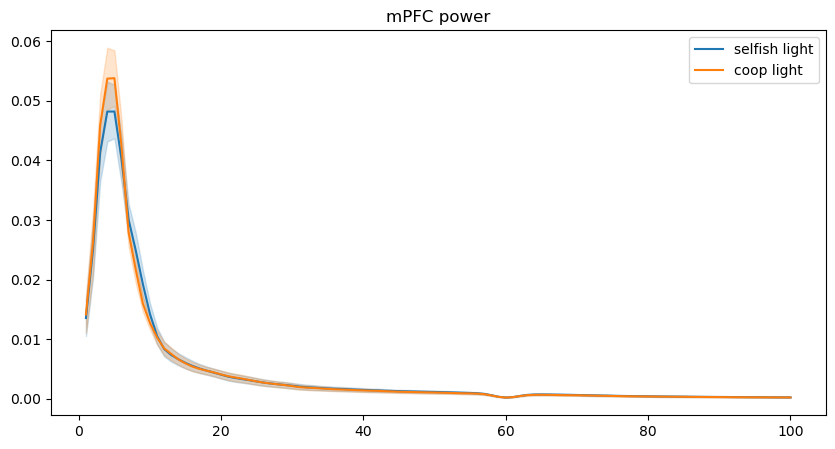

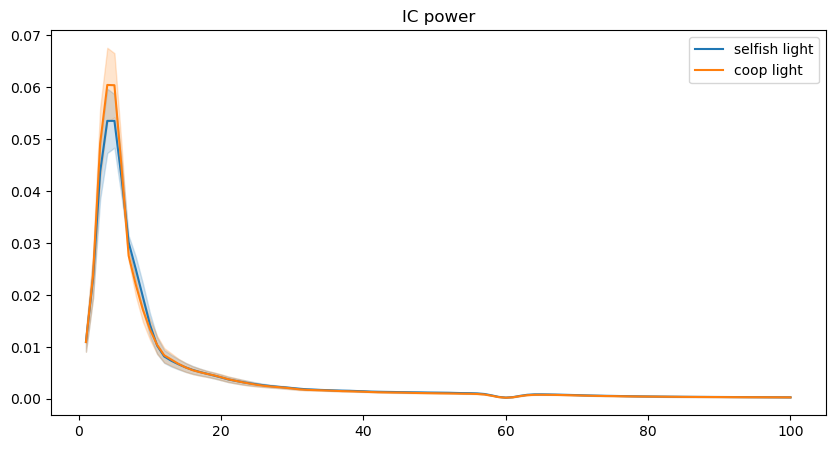

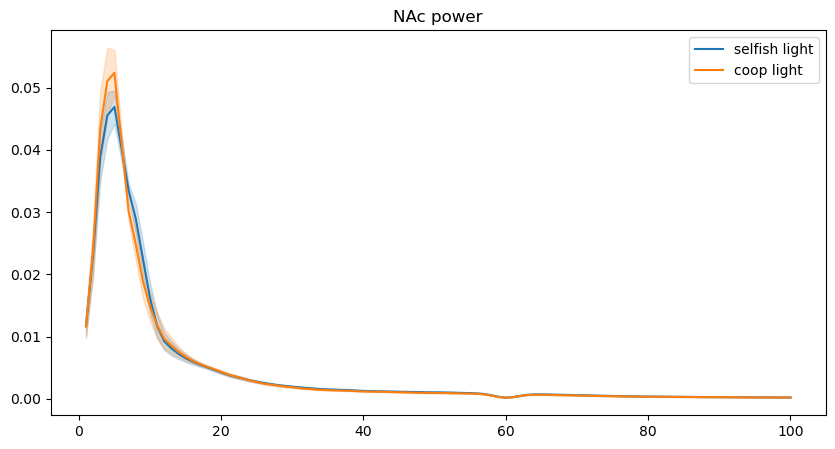

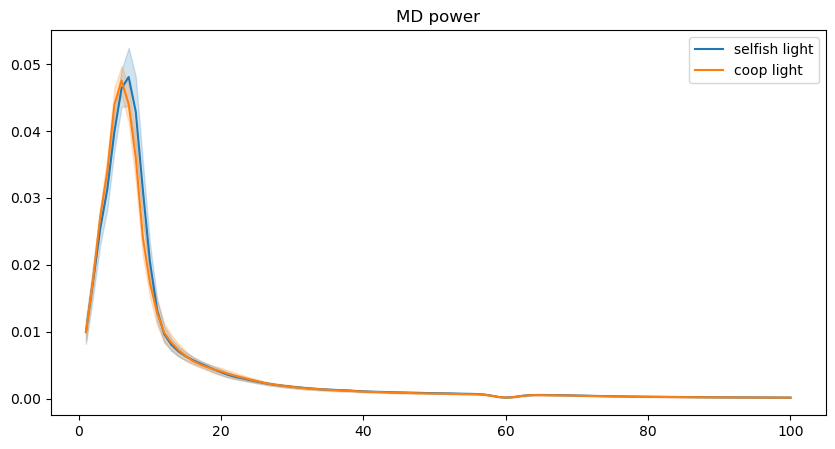

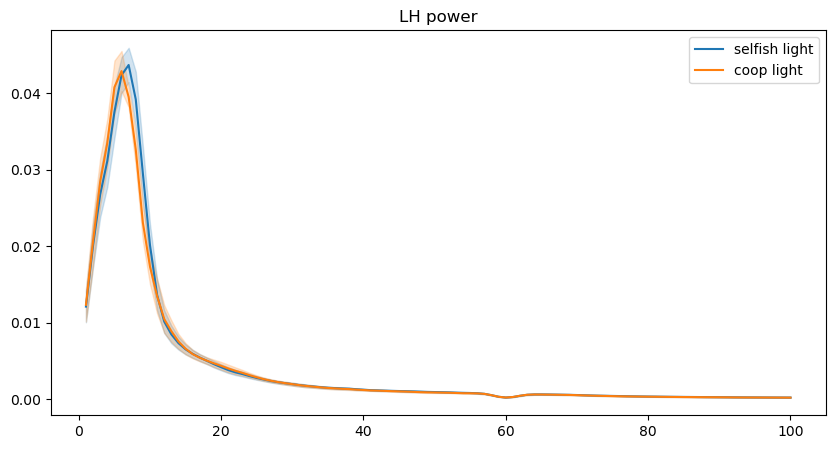

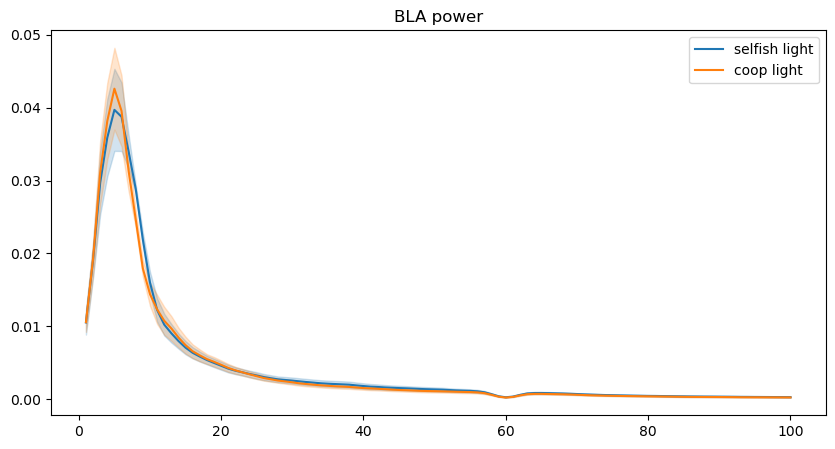

In [69]:
# CONDITION-AWARE EVENT SPECTRUM HELPER
from collections import defaultdict
from types import SimpleNamespace

import lfp.lfp_analysis.event_extraction as ee
import lfp.lfp_analysis.plotting as lfplt

condition_recordings = defaultdict(list, {
    'recipient': [
        '20250509_131426_Stage4_D1_4-1_merged.rec',
        '20250509_131426_Stage4_D1_4-2_merged.rec',
        '20250508_100203_Stage4_D1_2-1_merged.rec',
        '20250508_100203_Stage4_D1_1-3_merged.rec',
    ],
    'subject with recipient': [
        '20250508_100203_Stage4_D1_1-2_merged.rec',
        '20250509_131426_Stage4_D1_4-3_merged.rec',
        '20250508_100203_Stage4_D1_2-4_merged.rec',
        '20250509_131426_Stage4_D1_4-4_merged.rec',
    ],
    'subject alone': [
        '20250508_112121_Stage4_D1_6-1_merged.rec',
        '20250508_112121_Stage4_D1_6-3_merged.rec',
    ],
})

def condition_event_spectrum(
    lfp_collection,
    condition_recordings,
    selected_condition,
    events,
    mode='power',
    baseline=None,
    event_len=None,
    pre_window=0,
    post_window=0,
    regions=None,
    freq_range=None,
    plot=True,
):
    if isinstance(selected_condition, str):
        selected_conditions = [selected_condition]
    else:
        selected_conditions = list(selected_condition)

    missing_conditions = [condition for condition in selected_conditions if condition not in condition_recordings]
    if missing_conditions:
        raise ValueError(f"Condition(s) not found in condition_recordings: {missing_conditions}")

    selected_recording_names = []
    for condition in selected_conditions:
        selected_recording_names.extend(condition_recordings[condition])
    selected_recording_names = list(dict.fromkeys(selected_recording_names))

    selected_recording_set = set(selected_recording_names)
    filtered_recordings = [
        recording
        for recording in lfp_collection.recordings
        if recording.name in selected_recording_set
    ]

    if not filtered_recordings:
        raise ValueError(
            f"No recordings for selected_condition={selected_condition} were found in this LFP collection."
        )

    print(
        f"Calculating {mode} event spectrum for condition(s) {selected_conditions} "
        f"using {len(filtered_recordings)} recording(s)."
    )

    filtered_collection = SimpleNamespace(
        recordings=filtered_recordings,
        brain_region_dict=lfp_collection.brain_region_dict,
    )

    event_averages = ee.average_events(
        filtered_collection,
        events=events,
        mode=mode,
        baseline=baseline,
        event_len=event_len,
        pre_window=pre_window,
        post_window=post_window,
        plot=False,
    )


    if plot:
        lfplt.plot_event_spectrum(
            lfp_collection,
            event_averages,
            mode=mode,
            regions=regions,
            freq_range=freq_range,
        )

    return event_averages

event_averages = condition_event_spectrum(
    collection,
    condition_recordings=condition_recordings,
    selected_condition='recipient',
    events=['selfish light', 'coop light'],
    mode='power',
)

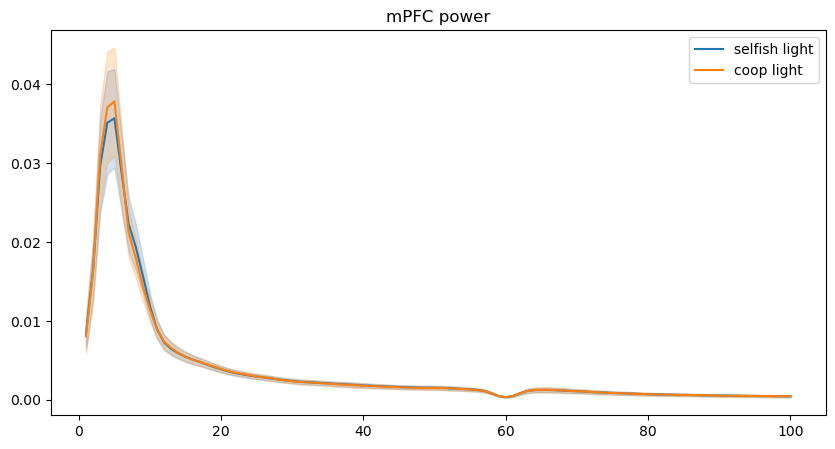

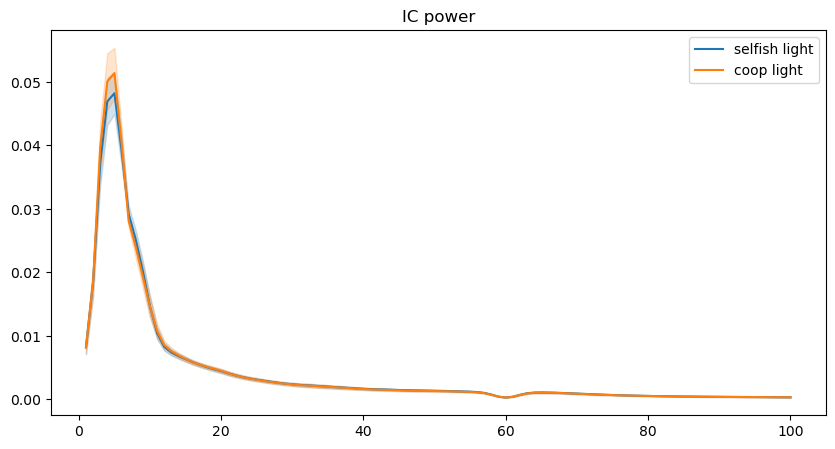

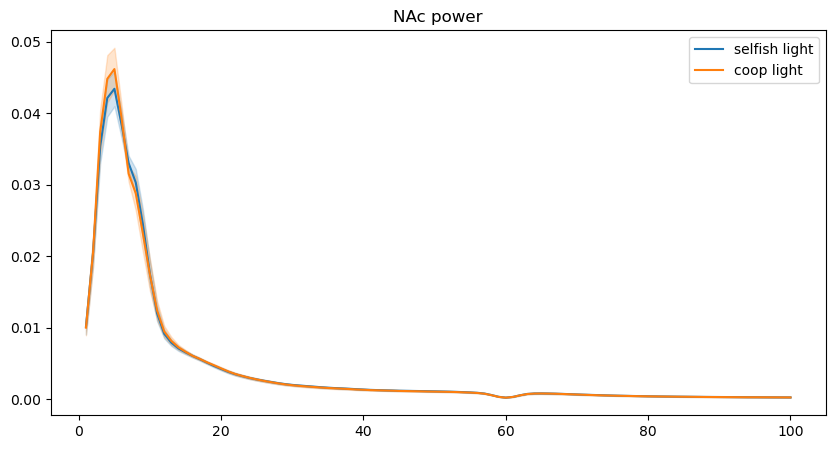

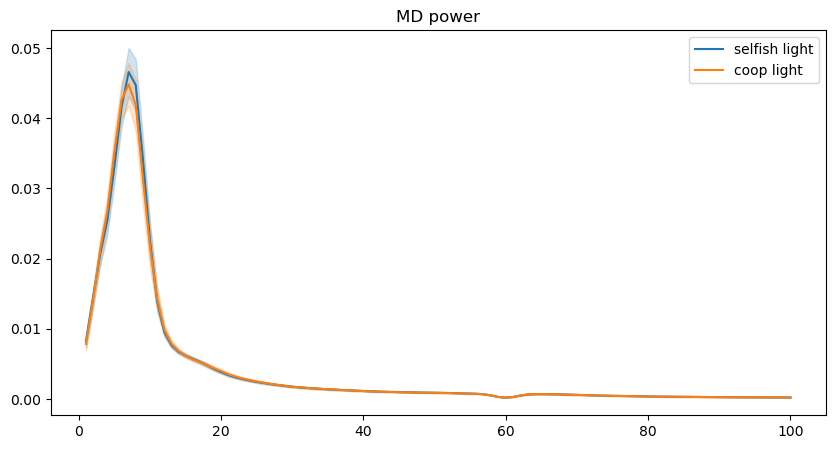

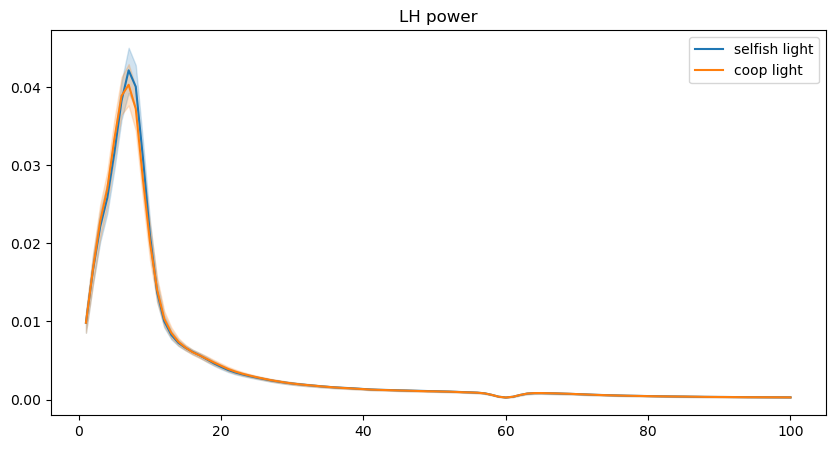

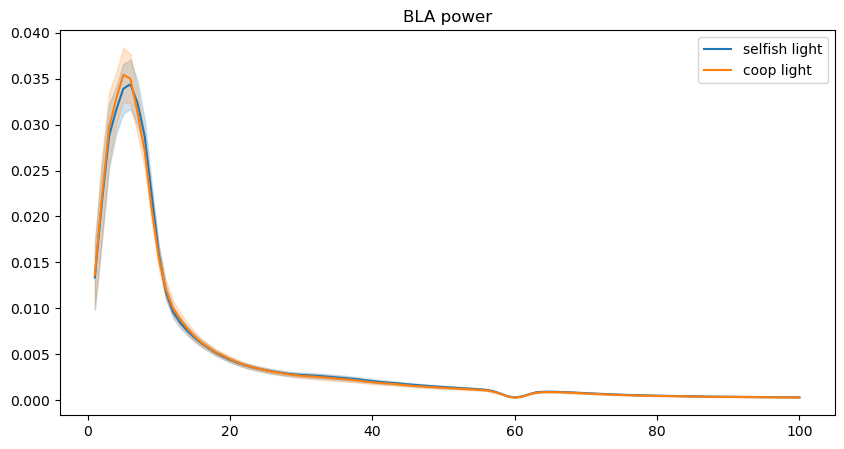

In [65]:
import lfp.lfp_analysis.event_extraction as ee
import lfp.lfp_analysis.plotting as lfplt

event_averages = ee.average_events(
                        collection,
                        events=['selfish light', 'coop light'],
                        mode='power',
                        plot=False
                    )
lfplt.plot_event_spectrum(
    collection,
    event_averages,
    mode='power',
)

In [ ]:
# import numpy as np
# def random_event_generator(start, stop, len_event, no_events):
#     total_duration = stop - start
#     possible_events = np.arange(int(total_duration / len_event))
#     pot_events = np.random.choice(possible_events, size = (no_events), replace = False)
#     pot_events = np.sort(pot_events)
#     events = []
#     for i in pot_events: 
#         event_start = (start + (len_event * i))
#         event_stop = (event_start + (len_event))
#         events.append(np.array([event_start, event_stop]))
#     return(np.array(events))


In [ ]:
# for recording in collection.recordings: 
#     start = 0
#     stop = recording.power.shape[0]*0.5*1000 
#     recording.event_dict = {}
#     random_events = random_event_generator(start, stop, len_event = 10000, no_events = 30)
    
#     recording.event_dict['random event'] = random_events

In [ ]:
# # os.chdir('/blue/npadillacoreano/mcum/SocialMemEphys/diff_fam_social_memory_ephys')
# import lfp.lfp_analysis.event_extraction as ee
# def average_events_condition(
#     lfp_collection, events, mode, condition_dict, baseline=None, event_len=None, pre_window=0, post_window=0, plot=False, regions = None, freq_range = None):
#     """
#     Calculates average event measurement (power, coherence, or granger) per recording then
#     calculates global averages across all recordings from recording averages (to account for
#     differences in event numbers per recording)
#     """
#     event_averages_dict = {}
#     recordings = lfp_collection.recordings
#     if baseline is not None:
#         if (len(events) != len(baseline)) and (len(baseline) == 1):
#             baseline = baseline * len(events)
#     for i in range(len(events)):
#         for condition, recording_list in condition_dict.items():
#             recording_averages = []
#             for recording in recordings:
#                 if recording.name in recording_list:
#                     event_averages = ee.get_events(recording, events[i], mode, event_len, pre_window, post_window, average = True)
#                     if baseline is not None:
#                         adj_averages = ee.__baseline_diff__(
#                             recording, event_averages, baseline[i], mode, event_len, pre_window=0, post_window=0, average = True
#                         )
#                         rec_event_average = np.mean(np.array(adj_averages), axis = 0)
#                         recording_averages.append(rec_event_average)
#                     else:
#                         rec_event_average = np.mean(np.array(event_averages), axis = 0)
#                         recording_averages.append(rec_event_average)

#                 # recording_averages = [recs, b, f] or [recs, b, b, f]
#             print(np.array(recording_averages).shape)    
#             event_averages_dict[condition] = recording_averages
#         if plot:
#             lfplt.plot_average_events(lfp_collection, event_averages_dict, mode, regions, freq_range)
#         return event_averages_dict
    
# condition_coherence = average_events_condition(collection, events = ['selfish light'], mode = 'coherence', condition_dict = condition_dict)
# condition_power = average_events_condition(collection, events = ['selfish light'], mode = 'power', condition_dict = condition_dict)

In [ ]:
# del condition_power['recipient']
# del condition_coherence['recipient']

In [ ]:
import lfp.lfp_analysis.plotting as lfplt
from importlib import reload
reload(lfplt)

lfplt.plot_event_spectrum(collection, condition_power, mode = 'power')
lfplt.plot_event_spectrum(collection, condition_coherence, mode = 'coherence')

In [ ]:
def event_power_bar(lfp_collection, events, baseline=None):
    powers = ee.average_events(lfp_collection, events=events, mode="power", baseline=baseline, plot=False)
    [unflipped, flipped] = band_calcs(powers)
    brain_regions = np.empty(len(lfp_collection.brain_region_dict.keys()), dtype="<U10")
    for i in range(len(lfp_collection.brain_region_dict.keys())):
        brain_regions[i] = lfp_collection.brain_region_dict.inverse[i]
    avg_values = {key: {subset: {event: [] for event in events} for subset in brain_regions} for key in flipped.keys()}
    sem_values = {key: {subset: {event: [] for event in events} for subset in brain_regions} for key in flipped.keys()}
    for key in flipped.keys():
        for i, subset in enumerate(brain_regions):
            for event in events:
                avg_values[key][subset][event] = np.nanmean(flipped[key][event][:, i])
                sem_values[key][subset][event] = stats.sem(flipped[key][event][:, i], nan_policy="omit")

    # Adjust bar width and spacing based on number of events
    total_width = 0.8  # Total width available for each group of bars
    bar_width = total_width / len(events)  # Width of each bar
    col = cm.rainbow(np.linspace(0, 1, len(events)))

    # Spacing between groups of bars
    group_spacing = 1  # Increased for better separation between brain regions

    sorted_avg_values = {key: {subset: avg_values[key][subset] for subset in brain_regions} for key in flipped.keys()}
    sorted_sem_values = {key: {subset: sem_values[key][subset] for subset in brain_regions} for key in flipped.keys()}

    # Create a separate plot for each key
    for key in flipped.keys():
        plt.figure(figsize=(25, 10))
        x = np.arange(len(brain_regions)) * group_spacing  # x-axis positions for subsets

        for i, subset in enumerate(brain_regions):
            for k, event in enumerate(events):
                # Center the group of bars and space them evenly
                center = x[i]
                offset = (k - (len(events) - 1) / 2) * bar_width
                position = center + offset

                plt.bar(
                    position,
                    sorted_avg_values[key][subset][event],
                    width=bar_width,
                    yerr=sorted_sem_values[key][subset][event],
                    capsize=5,
                    linewidth=2,
                    error_kw={"elinewidth": 2, "capthick": 2},
                    color=col[k],
                    label=event if i == 0 else "",
                )

        plt.yticks(fontsize=20)
        plt.xticks(x, brain_regions, fontsize=24, rotation=45)
        plt.axhline(y=0, color="black", linestyle="--", alpha=0.8)
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.gca().spines["bottom"].set_linewidth(2)
        plt.gca().spines["left"].set_linewidth(2)
        plt.title(f"Average Power for {key}", fontsize=40)
        plt.legend(fontsize=26, frameon=False)
        plt.subplots_adjust(hspace=0.5)
        plt.show()
